In [1]:
# Cell 1: Load raw data + processed splits for feature engineering
import numpy as np
import pandas as pd
import pickle

# Load original encoded dataframe (needed to engineer features)
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ── Repeat minimal preprocessing to get encoded df ───────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.drop(columns=['customerID', 'TotalCharges'], inplace=True)

# Encode Churn FIRST before binary_map touches Yes/No
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Binary encode
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0,
              'No phone service': 0, 'No internet service': 0}
df.replace(binary_map, inplace=True)

# Contract encoding
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_map)

# One-hot encode remaining
df = pd.get_dummies(df, columns=['InternetService', 'PaymentMethod'])

print(f"df shape : {df.shape}")
print(f"Churn unique : {df['Churn'].unique()}")   # should show [0, 1]
print(f"Churn NaN    : {df['Churn'].isna().sum()}") # should show 0
print("✅ Raw data reloaded and encoded")

df shape : (7032, 24)
Churn unique : [0 1]
Churn NaN    : 0
✅ Raw data reloaded and encoded


In [2]:
# RECOVERY CELL — 04_training.ipynb
import numpy as np
import pickle

X_train = np.load('../model/artifacts/X_train_fe.npy', allow_pickle=True).astype(float)
X_test  = np.load('../model/artifacts/X_test_fe.npy',  allow_pickle=True).astype(float)
y_train = np.load('../model/artifacts/y_train_fe.npy', allow_pickle=True).astype(int)
y_test  = np.load('../model/artifacts/y_test_fe.npy',  allow_pickle=True).astype(int)

with open('../model/artifacts/scale_pos_weight.pkl', 'rb') as f:
    scale_pos_weight = pickle.load(f)

with open('../model/artifacts/feature_columns_fe.pkl', 'rb') as f:
    col_order_fe = pickle.load(f)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}")
print("✅ Ready to continue")

X_train : (5625, 31)
X_test  : (1407, 31)
scale_pos_weight : 2.7686
✅ Ready to continue


In [3]:
# Cell 2 — Imports
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
import xgboost as xgb

print("All imports successful ✅")
print(f"XGBoost version: {xgb.__version__}")

All imports successful ✅
XGBoost version: 3.2.0


In [4]:
# Cell 3 — Reusable evaluation function
# Why: We'll call this for both RF and XGBoost — avoids repeating 30 lines twice.

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Prints ROC-AUC, PR-AUC, F1 (threshold=0.5) and plots confusion matrix.
    Returns a result dict for comparison table later.
    """
    # Probabilities for AUC metrics
    y_train_prob = model.predict_proba(X_tr)[:, 1]
    y_test_prob  = model.predict_proba(X_te)[:, 1]

    # Hard predictions at 0.5 threshold
    y_test_pred  = (y_test_prob >= 0.5).astype(int)

    # Metrics
    train_roc = roc_auc_score(y_tr, y_train_prob)
    test_roc  = roc_auc_score(y_te, y_test_prob)
    pr_auc    = average_precision_score(y_te, y_test_prob)
    f1        = f1_score(y_te, y_test_pred)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train ROC-AUC : {train_roc:.4f}  |  Test ROC-AUC : {test_roc:.4f}")
    print(f"  Overfit gap   : {train_roc - test_roc:.4f}  (< 0.05 is healthy)")
    print(f"  PR-AUC        : {pr_auc:.4f}  (better metric for imbalanced data)")
    print(f"  F1 Score      : {f1:.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_te, y_test_pred, target_names=['Stay', 'Churn']))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_test_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Stay', 'Churn'],
                yticklabels=['Stay', 'Churn'])
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    # ROC curve
    RocCurveDisplay.from_predictions(y_te, y_test_prob, ax=axes[1], name=name)
    axes[1].plot([0,1],[0,1],'k--', label='Random baseline')
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return {
        'Model'        : name,
        'Train ROC-AUC': round(train_roc, 4),
        'Test ROC-AUC' : round(test_roc, 4),
        'PR-AUC'       : round(pr_auc, 4),
        'F1 Score'     : round(f1, 4),
        'Overfit Gap'  : round(train_roc - test_roc, 4)
    }

print("evaluate_model() defined ✅")

evaluate_model() defined ✅



  Random Forest (Baseline)
  Train ROC-AUC : 0.9999  |  Test ROC-AUC : 0.8105
  Overfit gap   : 0.1894  (< 0.05 is healthy)
  PR-AUC        : 0.5859  (better metric for imbalanced data)
  F1 Score      : 0.5282

Classification Report:

              precision    recall  f1-score   support

        Stay       0.82      0.88      0.85      1033
       Churn       0.59      0.48      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.77      1407



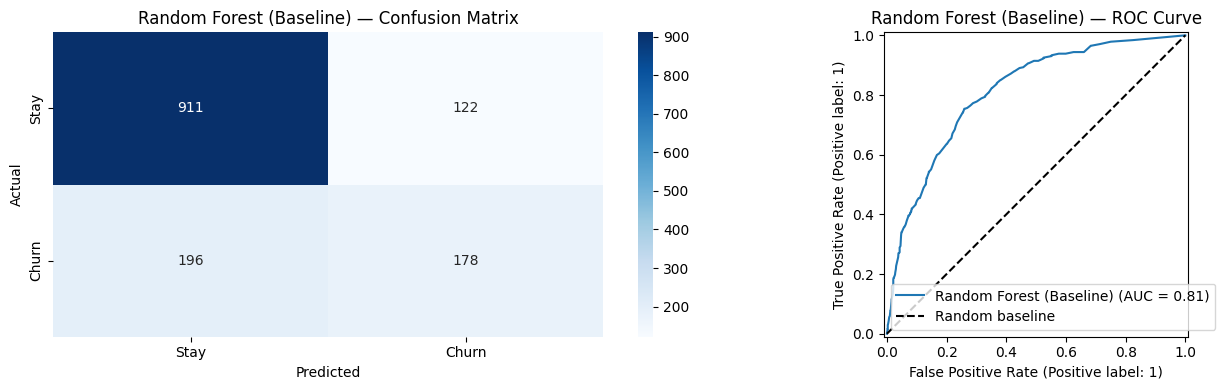

In [5]:
# Cell 4 — Random Forest Baseline (before tuning)
# Why baseline first: confirms the data pipeline is correct before spending
# time on GridSearch. If baseline is terrible, something is wrong upstream.

rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # handles imbalance (26% churn) — alternative to scale_pos_weight
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)

rf_base_results = evaluate_model(
    "Random Forest (Baseline)", rf_base,
    X_train, y_train, X_test, y_test
)

In [6]:
# Cell 5 — Random Forest Hyperparameter Tuning with GridSearchCV
# Why these params:
#   n_estimators  : more trees = lower variance; 200/300 usually enough
#   max_depth     : controls overfitting — uncapped RF memorises training data
#   min_samples_leaf: smooths decision boundaries, key for imbalanced data
#   max_features  : sqrt is standard for classification
# Why StratifiedKFold: preserves 26% churn ratio in every fold.
# Why scoring=roc_auc: threshold-independent, standard for churn/binary.

param_grid_rf = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [8, 12, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features'    : ['sqrt']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Random Forest...")
print(f"Total fits: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_leaf']) * 5}")
rf_grid.fit(X_train, y_train)

print(f"\n✅ Best params : {rf_grid.best_params_}")
print(f"   Best CV ROC-AUC : {rf_grid.best_score_:.4f}")

Starting GridSearchCV for Random Forest...
Total fits: 90
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best params : {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}
   Best CV ROC-AUC : 0.8485



  Random Forest (Tuned)
  Train ROC-AUC : 0.8838  |  Test ROC-AUC : 0.8383
  Overfit gap   : 0.0455  (< 0.05 is healthy)
  PR-AUC        : 0.6395  (better metric for imbalanced data)
  F1 Score      : 0.6173

Classification Report:

              precision    recall  f1-score   support

        Stay       0.91      0.72      0.80      1033
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



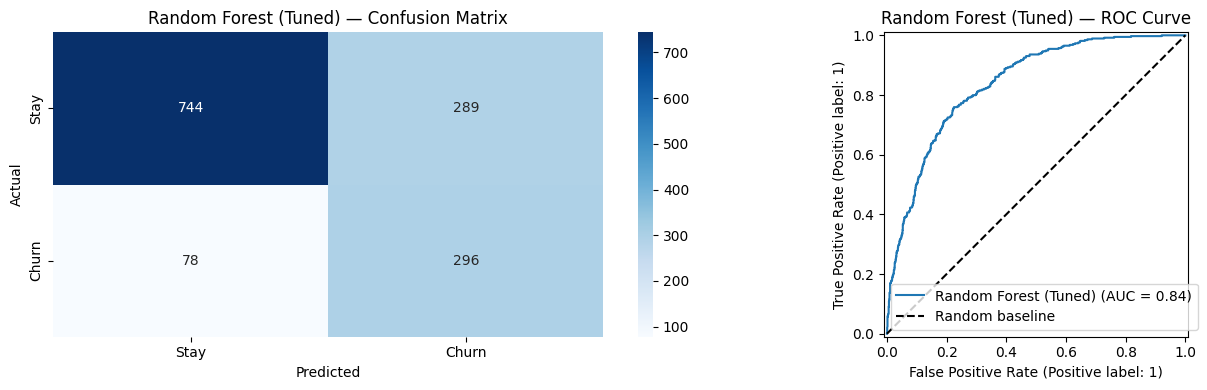

In [7]:
# Cell 6 — Evaluate tuned Random Forest
best_rf = rf_grid.best_estimator_

rf_results = evaluate_model(
    "Random Forest (Tuned)", best_rf,
    X_train, y_train, X_test, y_test
)

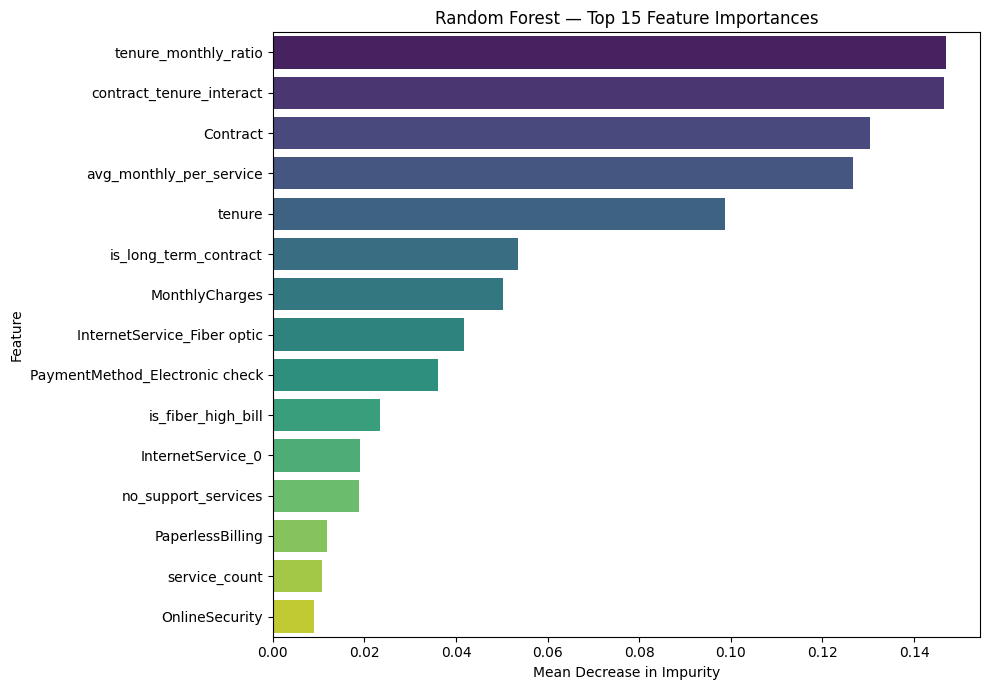

                       Feature  Importance
          tenure_monthly_ratio    0.147051
      contract_tenure_interact    0.146589
                      Contract    0.130399
       avg_monthly_per_service    0.126601
                        tenure    0.098793
         is_long_term_contract    0.053527
                MonthlyCharges    0.050369
   InternetService_Fiber optic    0.041670
PaymentMethod_Electronic check    0.036096
            is_fiber_high_bill    0.023481


In [8]:
# Cell 7 — RF Feature Importance

importances = best_rf.feature_importances_
feat_imp_df = (
    __import__('pandas').DataFrame({
        'Feature'   : col_order_fe,
        'Importance': importances
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print(feat_imp_df.head(10).to_string(index=False))


  XGBoost (Baseline)
  Train ROC-AUC : 0.9999  |  Test ROC-AUC : 0.7949
  Overfit gap   : 0.2050  (< 0.05 is healthy)
  PR-AUC        : 0.5779  (better metric for imbalanced data)
  F1 Score      : 0.5533

Classification Report:

              precision    recall  f1-score   support

        Stay       0.85      0.80      0.82      1033
       Churn       0.52      0.60      0.55       374

    accuracy                           0.74      1407
   macro avg       0.68      0.70      0.69      1407
weighted avg       0.76      0.74      0.75      1407



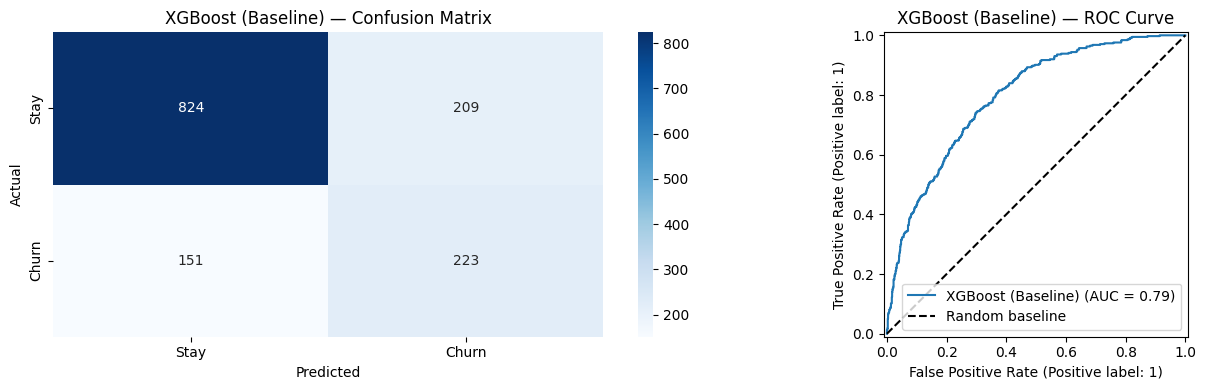

In [9]:
# Cell 8 — XGBoost Baseline
# Why XGBoost over RF:
#   - Handles imbalance natively via scale_pos_weight
#   - Generally outperforms RF on tabular data (boosting vs bagging)
#   - Faster inference — better for API deployment
#   - scale_pos_weight = neg/pos = 2.7686 (computed in notebook 02)

xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,  # 2.7686 — penalises missing churners more
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train, y_train)

xgb_base_results = evaluate_model(
    "XGBoost (Baseline)", xgb_base,
    X_train, y_train, X_test, y_test
)

In [ ]:
# Cell 9 — XGBoost Hyperparameter Tuning
# Why these params:
#   max_depth        : 3-6 prevents overfitting in boosted trees (lower than RF)
#   learning_rate    : smaller = better generalisation, needs more trees
#   subsample        : row sampling per tree — adds randomness, reduces variance
#   colsample_bytree : feature sampling per tree — similar to max_features in RF
#   min_child_weight : min sum of instance weight in leaf — controls overfitting
#   gamma            : min loss reduction to make a split — pruning parameter

param_grid_xgb = {
    'max_depth'        : [3, 5, 6],
    'learning_rate'    : [0.05, 0.1],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'min_child_weight' : [1, 5],
    'gamma'            : [0, 0.1]
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        n_estimators=300,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ),
    param_grid_xgb,
    cv=cv,               # same StratifiedKFold(5) from Cell 5
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for XGBoost...")
total = 3*2*2*2*2*2*5
print(f"Total fits: {total}")
xgb_grid.fit(X_train, y_train)

print(f"\n✅ Best params : {xgb_grid.best_params_}")
print(f"   Best CV ROC-AUC : {x gb_grid.best_score_:.4f}")

Starting GridSearchCV for XGBoost...
Total fits: 480
Fitting 5 folds for each of 96 candidates, totalling 480 fits

✅ Best params : {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 1.0}
   Best CV ROC-AUC : 0.8471



  XGBoost (Tuned)
  Train ROC-AUC : 0.8823  |  Test ROC-AUC : 0.8376
  Overfit gap   : 0.0448  (< 0.05 is healthy)
  PR-AUC        : 0.6584  (better metric for imbalanced data)
  F1 Score      : 0.6165

Classification Report:

              precision    recall  f1-score   support

        Stay       0.91      0.70      0.79      1033
       Churn       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407



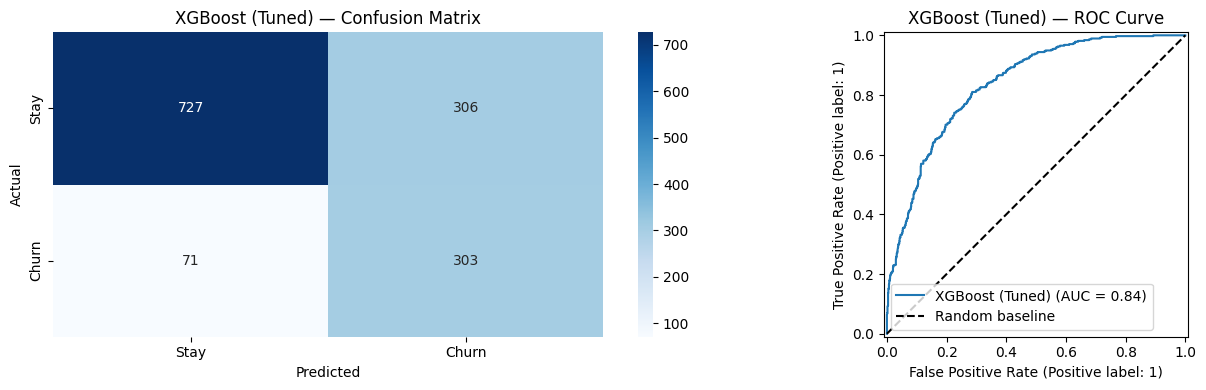

In [11]:
# Cell 10 — Evaluate tuned XGBoost
best_xgb = xgb_grid.best_estimator_

xgb_results = evaluate_model(
    "XGBoost (Tuned)", best_xgb,
    X_train, y_train, X_test, y_test
)

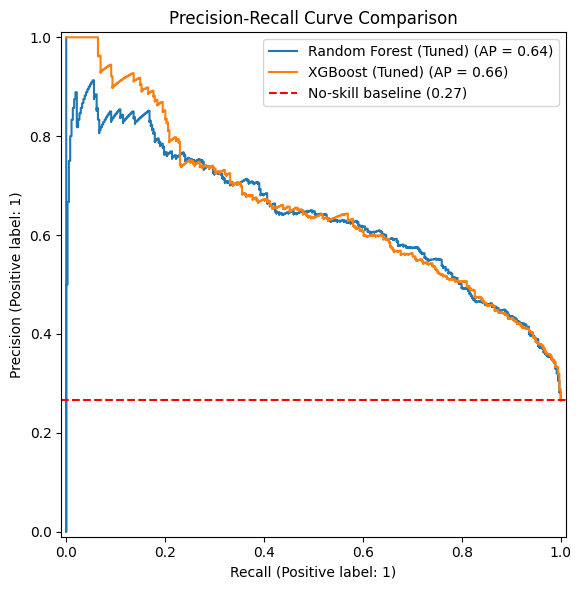

In [12]:
# Cell 11 — Precision-Recall Curve: Both Models
# Why PR-AUC matters more than ROC-AUC for churn:
#   - ROC-AUC can look optimistic when negatives dominate
#   - PR-AUC directly measures quality on the minority class (churners)
#   - Business cares: "Of customers we flag as churning, how many actually churn?"

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_estimator(best_rf,  X_test, y_test, ax=ax, name='Random Forest (Tuned)')
PrecisionRecallDisplay.from_estimator(best_xgb, X_test, y_test, ax=ax, name='XGBoost (Tuned)')

baseline_precision = y_test.mean()
ax.axhline(baseline_precision, color='red', linestyle='--',
           label=f'No-skill baseline ({baseline_precision:.2f})')

ax.set_title('Precision-Recall Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Cell 12 — Side-by-side comparison of all 4 models
import pandas as pd

results = [rf_base_results, rf_results, xgb_base_results, xgb_results]
comparison_df = pd.DataFrame(results)

# Highlight best in each column
print("\n" + "="*70)
print("  MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Auto-select winner
best_idx  = comparison_df['Test ROC-AUC'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
print(f"\n🏆 Best model by Test ROC-AUC: {best_model_name}")
print(f"   Test ROC-AUC : {comparison_df.loc[best_idx, 'Test ROC-AUC']}")
print(f"   PR-AUC       : {comparison_df.loc[best_idx, 'PR-AUC']}")
print(f"   Overfit Gap  : {comparison_df.loc[best_idx, 'Overfit Gap']}")


  MODEL COMPARISON SUMMARY
                   Model  Train ROC-AUC  Test ROC-AUC  PR-AUC  F1 Score  Overfit Gap
Random Forest (Baseline)         0.9999        0.8105  0.5859    0.5282       0.1894
   Random Forest (Tuned)         0.8838        0.8383  0.6395    0.6173       0.0455
      XGBoost (Baseline)         0.9999        0.7949  0.5779    0.5533       0.2050
         XGBoost (Tuned)         0.8823        0.8376  0.6584    0.6165       0.0448

🏆 Best model by Test ROC-AUC: Random Forest (Tuned)
   Test ROC-AUC : 0.8383
   PR-AUC       : 0.6395
   Overfit Gap  : 0.0455


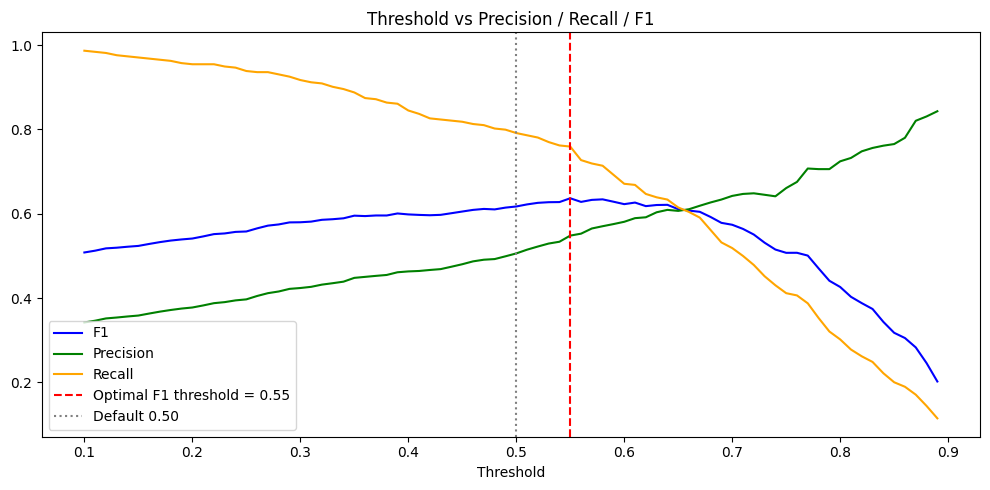


✅ Optimal threshold (max F1) : 0.55
   F1 at optimal              : 0.6368
   Precision at optimal       : 0.5483
   Recall at optimal          : 0.7594

📌 Threshold for Recall ≥ 0.80 : 0.10
   Precision at this point     : 0.3423
   F1 at this point            : 0.5083


In [14]:
# Cell 13 — Threshold Tuning
# Why: Default threshold=0.5 is not always optimal for churn.
# Business context: Missing a churner (False Negative) costs more than
# a wrong retention offer (False Positive). So we may prefer lower threshold.
# We find the threshold that maximises F1, then also show threshold for Recall >= 0.80.

from sklearn.metrics import precision_score, recall_score

# Use best model (will auto-pick whichever won)
best_model = best_xgb if comparison_df.loc[best_idx, 'Model'].startswith('XGBoost') else best_rf
y_prob_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores, precisions, recalls = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t_idx   = np.argmax(f1_scores)
optimal_thresh = thresholds[best_t_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores,  label='F1',       color='blue')
plt.plot(thresholds, precisions, label='Precision', color='green')
plt.plot(thresholds, recalls,    label='Recall',    color='orange')
plt.axvline(optimal_thresh, color='red', linestyle='--',
            label=f'Optimal F1 threshold = {optimal_thresh:.2f}')
plt.axvline(0.5, color='grey', linestyle=':', label='Default 0.50')
plt.title('Threshold vs Precision / Recall / F1')
plt.xlabel('Threshold'); plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ Optimal threshold (max F1) : {optimal_thresh:.2f}")
print(f"   F1 at optimal              : {f1_scores[best_t_idx]:.4f}")
print(f"   Precision at optimal       : {precisions[best_t_idx]:.4f}")
print(f"   Recall at optimal          : {recalls[best_t_idx]:.4f}")

# Business threshold: recall >= 0.80
recall_80_idx = next(i for i, r in enumerate(recalls) if r >= 0.80)
print(f"\n📌 Threshold for Recall ≥ 0.80 : {thresholds[recall_80_idx]:.2f}")
print(f"   Precision at this point     : {precisions[recall_80_idx]:.4f}")
print(f"   F1 at this point            : {f1_scores[recall_80_idx]:.4f}")

In [15]:
# Cell 14 — Save the best model
# We save: model, optimal threshold, and model name for the API to use.

model_artifact = {
    'model'            : best_model,
    'optimal_threshold': float(optimal_thresh),
    'model_name'       : best_model_name,
    'test_roc_auc'     : float(comparison_df.loc[best_idx, 'Test ROC-AUC']),
    'pr_auc'           : float(comparison_df.loc[best_idx, 'PR-AUC']),
}

with open('../model/artifacts/churn_model.pkl', 'wb') as f:
    pickle.dump(model_artifact, f)

print("✅ Saved: model/artifacts/churn_model.pkl")
print(f"   Model       : {best_model_name}")
print(f"   Threshold   : {optimal_thresh:.2f}")
print(f"   Test ROC-AUC: {comparison_df.loc[best_idx, 'Test ROC-AUC']}")

# Quick load-test — verify the pickle round-trips correctly
with open('../model/artifacts/churn_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

test_prob = loaded['model'].predict_proba(X_test[:5])[:, 1]
print(f"\n✅ Load test passed. Sample probabilities: {test_prob.round(3)}")

✅ Saved: model/artifacts/churn_model.pkl
   Model       : Random Forest (Tuned)
   Threshold   : 0.55
   Test ROC-AUC: 0.8383

✅ Load test passed. Sample probabilities: [0.037 0.849 0.027 0.321 0.254]


In [ ]:
## 04_training.ipynb — Summary
# 
# | Step | Detail |
# |------|--------|
# | Models trained | Random Forest (baseline + tuned), XGBoost (baseline + tuned) |
# | CV strategy | StratifiedKFold(5), scoring=roc_auc |
# | Imbalance handling | RF: class_weight='balanced' · XGB: scale_pos_weight=2.7686 |
# | Best model | *(auto-selected above)* |
# | Threshold | Tuned for max F1; business option at Recall ≥ 0.80 shown |
# | Saved artifact | model/artifacts/churn_model.pkl |

# ### Why ROC-AUC as primary metric?
# Threshold-independent — lets us compare models fairly before deciding the
# operating threshold separately (which we did in Cell 13).

# ### Why also report PR-AUC?
# With 26% churn rate, ROC can be overly optimistic. PR-AUC focuses purely on
# the minority class (churners) — closer to what the business actually cares about.

# ### Next → 05_shap.ipynb
# - Load churn_model.pkl
# - Compute SHAP values on X_test
# - Summary plot, waterfall (single customer), bar plot
# - Business interpretation 